# Notebook 03 Inference Analyst

## Research Question

RQ1: 
Berapa estimasi probabilitas sebuah issue bug (is_bug = 1) dapat diselesaikan dalam waktu <= 7 hari, dan seberapa tinggi tingkat ketidakpastian estimasi tersebut?

|Nama|Role|
|---|---|
|Riyadh Fadilah| Inference Analyst|

## Penggunaan AI 

**Anggota:** [Riyadh Fadilah] — [Inference Analyst] | 
**Tools used:** [Gemini]

| Task | Tool | Prompt summary | Output modified? |
| ----------------------------- | ------ | ------------------------------------------------- | ----------------------- |
| Membuat struktur fungsi custom inference.py pada direktori src/ | Gemini | "Berikan saya struktur penggunaan fungsi def untuk dipanggil ke file direktori lain" | Ya - disesuaikan dengan kebutuhan |
| Memahami alur kerja (pipeline) pada Confidence Interval | Gemini & Notebooklm | "Berikan saya contoh implementasi penggunaan confidence interval sesuai dengan aturan formula Tsun (2020) | Ya - disesuaikan dengan sumber data yang sudah dikerjakan oleh data engineer, dan hasil estimasi yang dikerjakan oleh estimation analyst |

**Ditulis tanpa AI:** Interpretasi

## Import Library, Menentukan Path, & Import Fungsi

In [68]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from src.inference import (
    ci_bernoulli,
    ci_poisson,
    credible_interval
)

## Memuat Data dari Data Engineer & Estimation Analyst

In [69]:
# Mengambil data dari dataset_final.csv
df=pd.read_csv('../data/clean/dataset_final.csv')
df_bugs = df[df['is_bug'] == 1].copy()
df_bugs['closed_at'] = pd.to_datetime(df_bugs['closed_at'])
df_bugs['created_at'] = pd.to_datetime(df_bugs['created_at'])
bugs_per_minggu = df_bugs.resample('W', on='created_at').size()

# Mengubahnya menjadi list/array agar sesuai dengan argumen fungsi ci_poisson(data)
df_poisson = bugs_per_minggu.values

# Hasil perhitungan dari Estimation Analyst
k_sukses = 415
n_total = 778
alpha_posterior = 416 
beta_posterior = 364


## Confidence Interval Bernoulli

=== ANALISIS RQ1: PROBABILITAS BUG SELESAI <= 7 HARI ===
Confidence Interval 95%: [0.498, 0.568]
Titik estimasi terbaik: [0.533]


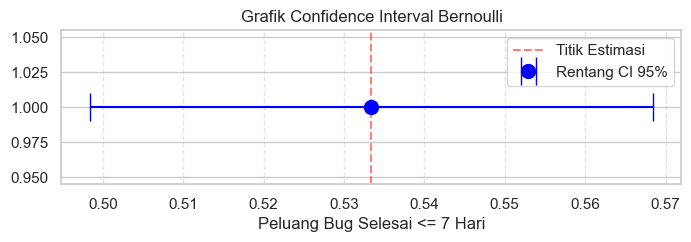

In [70]:
print("=== ANALISIS RQ1: PROBABILITAS BUG SELESAI <= 7 HARI ===")

# A. Confidence Interval Bernoulli 
lower_ci, upper_ci = ci_bernoulli (k = k_sukses, n = n_total, confidence=0.95)
print(f"Confidence Interval 95%: [{lower_ci:.3f}, {upper_ci:.3f}]")
print(f"Titik estimasi terbaik: [{k_sukses/n_total:.3f}]")

theta_hat = k_sukses / n_total
margin_of_error = upper_ci - theta_hat


plt.figure(figsize=(8, 2))
plt.errorbar(x=theta_hat,y=1, xerr=margin_of_error, fmt='o', color='blue',
             markersize=10, capsize=10, label='Rentang CI 95%')

plt.axvline(x=theta_hat, color='red', linestyle='--', alpha=0.5, label='Titik Estimasi')
plt.title('Grafik Confidence Interval Bernoulli')
plt.xlabel('Peluang Bug Selesai <= 7 Hari')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Berdasarkan hasil analisis tingkat kepercayaan, 95% dari prosedur serupa akan menghasilkan interval yang mengandung θ. 

## Credible Interval 


In [71]:
# B. Credible Interval 
lower_cred, upper_cred = credible_interval (alpha_posterior, beta_posterior, confidence=0.95)
print(f"Credible Interval 95%: [{lower_cred:.3f}, {upper_cred:.3f}]")

Credible Interval 95%: [0.498, 0.568]


Mengingat data yang kita miliki saat ini, terdapat probabilitas 95% bahwa peluang sebenarnya sebuah bug diselesaian dalam waktu 7 hari diantara rentang 0.498 dan 0.568

## Confidence Interval Poisson
Mengestimasikan laju frekuensi kejadian bug/minggu 

Confidence Interval 95% (Poisson): [6.955, 8.006] bug/minggu


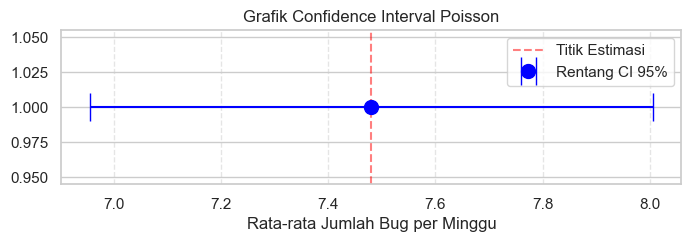

In [72]:
# C. Confidence Interval Poisson
lower_ci_poisson, upper_ci_poisson = ci_poisson (data=df_poisson, confidence=0.95)
print(f"Confidence Interval 95% (Poisson): [{lower_ci_poisson:.3f}, {upper_ci_poisson:.3f}] bug/minggu")

lambda_hat = sum(df_poisson) / len(df_poisson)
margin_of_error_poisson = upper_ci_poisson - lambda_hat

plt.figure(figsize=(8, 2))
plt.errorbar(x=lambda_hat,y=1, xerr=margin_of_error_poisson, fmt='o', color='blue',
             markersize=10, capsize=10, label='Rentang CI 95%')

plt.axvline(x=lambda_hat, color='red', linestyle='--', alpha=0.5, label='Titik Estimasi')
plt.title('Grafik Confidence Interval Poisson')
plt.xlabel('Rata-rata Jumlah Bug per Minggu')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Berdasarkan hasil Confidence Interval Poisson, 95% dari prosedur seperti ini akan menghasilkan interval yang mengandung θ.

Analisis telah membuktikan rentang atau interval kepercayaan mulai dari selesainya bug kurang dari 7 hari dan laju bug perminggu. Hasil analisis ini akan diteruskan kepada Computation Analyst sebagai pengambilan keputusan komputasi.